# Pertemuan 9 - Algoritma Klasifikasi Bagian 1

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Logistic Regression, Decision Tree, Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.


## 1. Import Library dan Load Dataset Breast Cancer


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape X:", X.shape)
print("Target names:", data.target_names)
display(X.head())
display(y.value_counts().rename_axis("target").reset_index(name="jumlah"))


Shape X: (569, 30)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,target,jumlah
0,1,357
1,0,212


## 2. Split Data dan Scaling


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (455, 30)
X_test: (114, 30)


## 3. Logistic Regression


Classification Report - Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



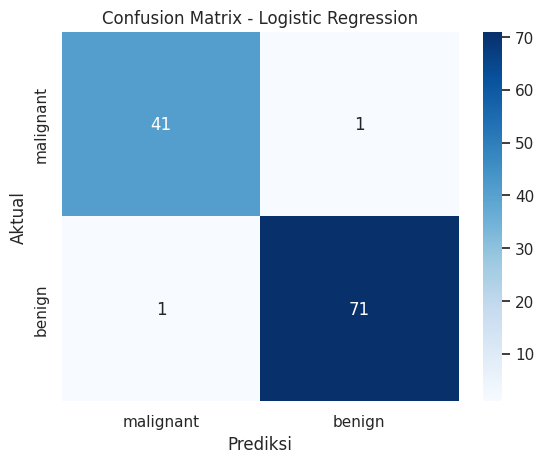

In [3]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log, target_names=data.target_names))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()


## 4. Decision Tree


Classification Report - Decision Tree
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



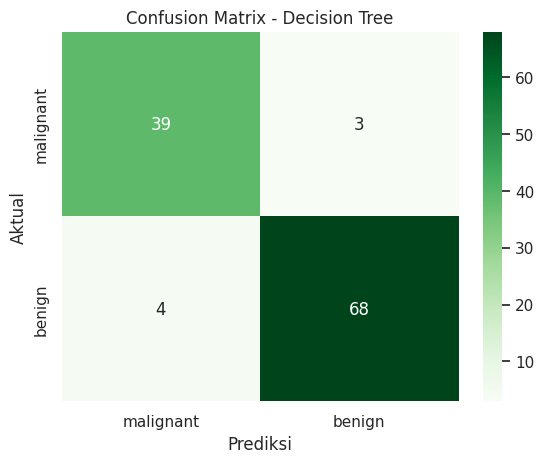

In [4]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()


## 5. Perbandingan Metrik


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982,0.986,0.986,0.986
1,Decision Tree,0.939,0.958,0.944,0.951


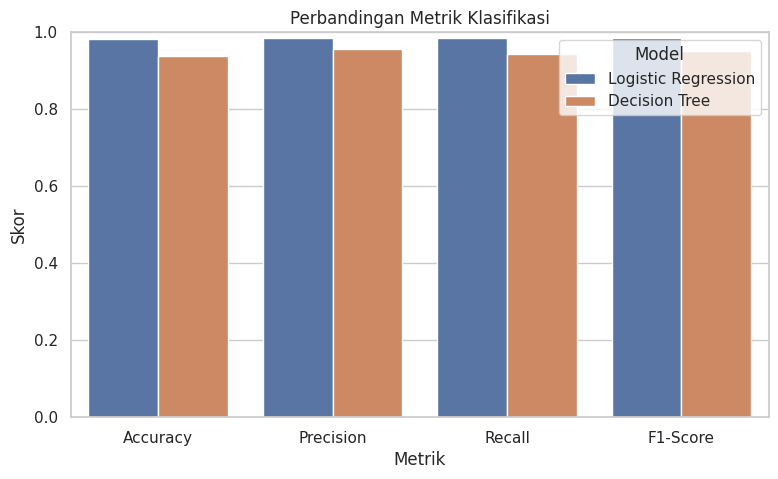

In [5]:
def get_metrics(y_true, y_pred, nama_model):
    return {
        "Model": nama_model,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

hasil = pd.DataFrame([
    get_metrics(y_test, y_pred_log, "Logistic Regression"),
    get_metrics(y_test, y_pred_tree, "Decision Tree")
])

display(hasil.round(3))

hasil_melt = hasil.melt(id_vars="Model", var_name="Metrik", value_name="Skor")
plt.figure(figsize=(9, 5))
sns.barplot(data=hasil_melt, x="Metrik", y="Skor", hue="Model")
plt.ylim(0, 1)
plt.title("Perbandingan Metrik Klasifikasi")
plt.show()


## 6. Interpretasi Metrik

Pada kasus diagnosis medis, **Recall** sangat penting karena model perlu meminimalkan kemungkinan pasien yang sebenarnya berisiko tetapi diprediksi aman. Namun Precision dan F1-Score juga tetap penting agar model tidak terlalu banyak memberikan alarm palsu. F1-Score membantu melihat keseimbangan Precision dan Recall.


## Kesimpulan

Saya mempelajari klasifikasi menggunakan Logistic Regression dan Decision Tree. Temuan utama adalah Logistic Regression dan Decision Tree dapat dibandingkan melalui confusion matrix, accuracy, precision, recall, dan F1-Score. Keterbatasannya, dataset ini relatif bersih sehingga belum menggambarkan masalah data dunia nyata secara penuh.
